In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Load the dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/newsgroups.json'
df = pd.read_json(url)
texts = df['content'].tolist()
print(texts[:5])

["From: lerxst@wam.umd.edu (where's my thing)\nSubject: WHAT car is this!?\nNntp-Posting-Host: rac3.wam.umd.edu\nOrganization: University of Maryland, College Park\nLines: 15\n\n I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.\n\nThanks,\n- IL\n   ---- brought to you by your neighborhood Lerxst ----\n\n\n\n\n", "From: guykuo@carson.u.washington.edu (Guy Kuo)\nSubject: SI Clock Poll - Final Call\nSummary: Final call for SI clock reports\nKeywords: SI,acceleration,clock,upgrade\nArticle-I.D.: shelley.1qvfo9INNc3s\nOrganization: University of Washington\nLines: 1

In [2]:
# Preprocessing function
def preprocess(text):
# Remove special characters and digits
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d', ' ', text)
    text = text.lower()
    # Tokenize
    words = word_tokenize(text)
    # Remove stopwords
    words = [word for word in words if word not in stopwords.words('english')]
    return words 

In [3]:
# Preprocess the texts
processed_texts = [preprocess(text) for text in texts]

In [4]:
%pip install --upgrade gensim
from gensim.models import Word2Vec

# Train Word2Vec model
model = Word2Vec(sentences=processed_texts, vector_size=100, window=5, min_count=5, workers=4)
   # Save the model
model.save("word2vec.model")



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


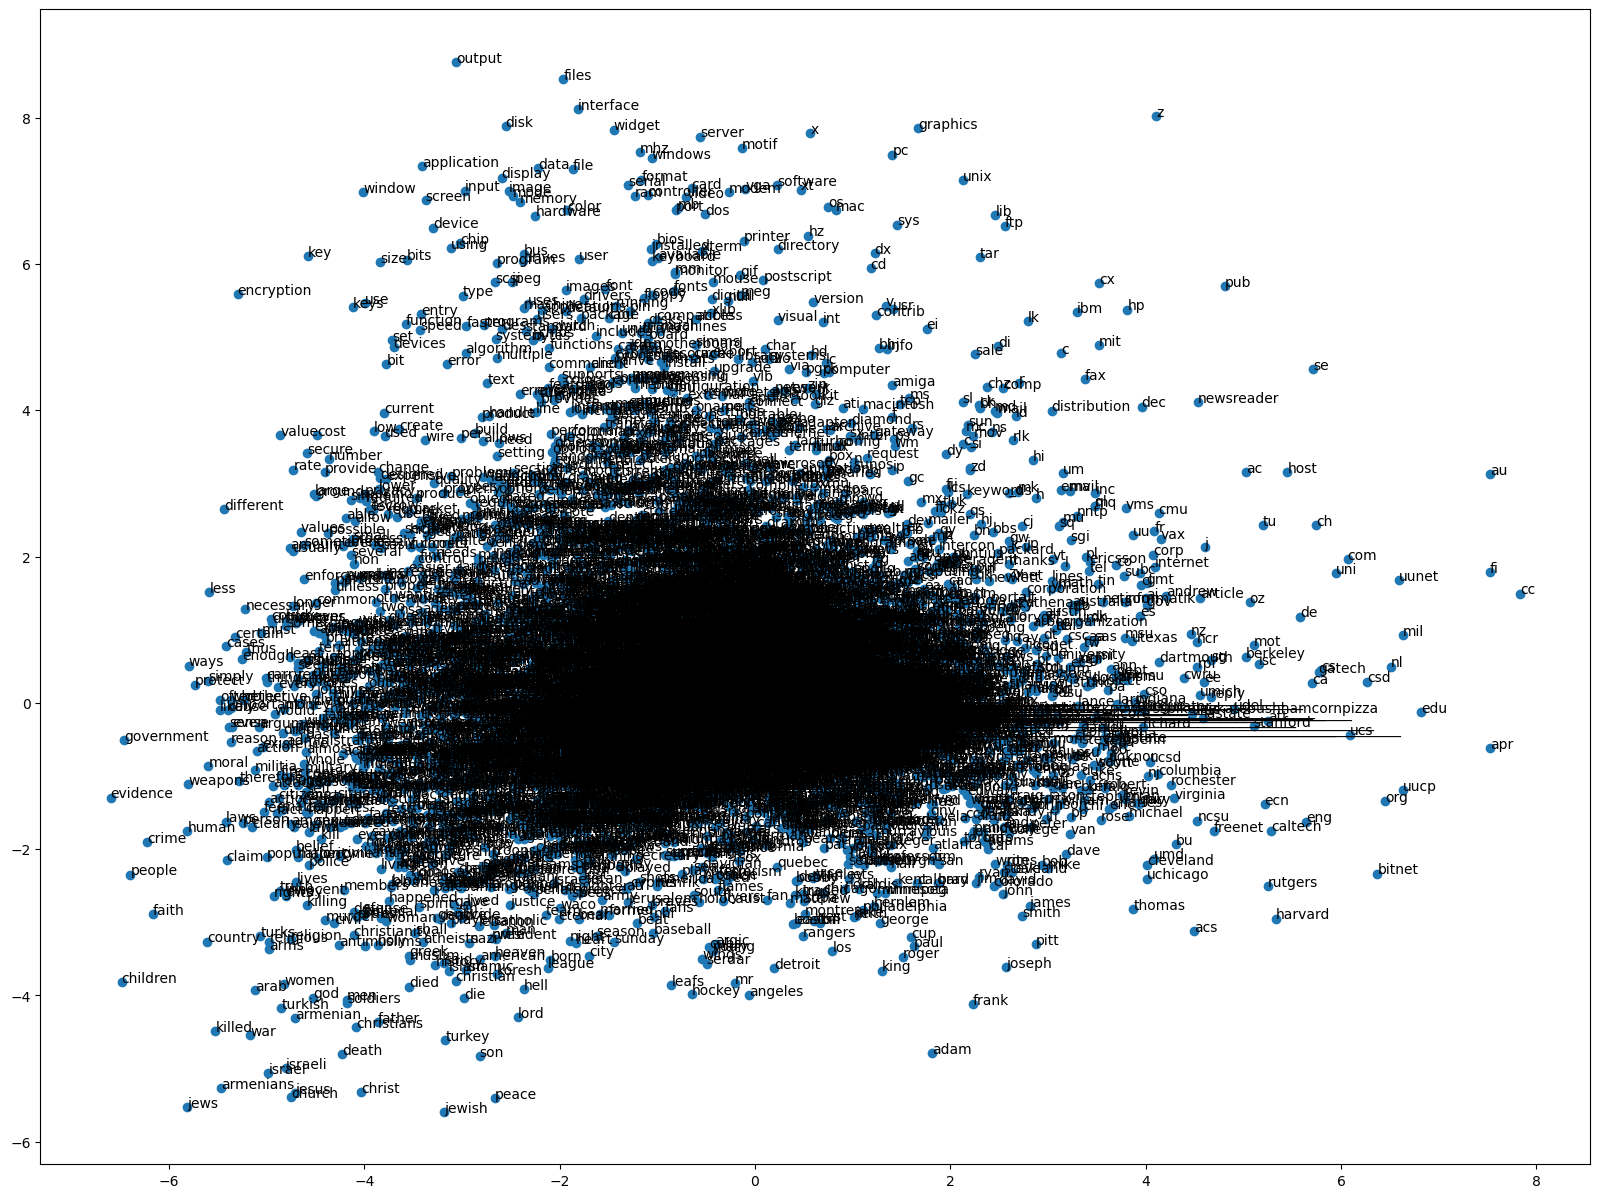

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
    # Load the model
model = Word2Vec.load("word2vec.model")
# Get word vectors
words = list(model.wv.index_to_key)
word_vectors = model.wv[words]
# Reduce dimensions using PCA
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)
# Create a scatter plot
plt.figure(figsize=(20, 15))
plt.scatter(result[:, 0], result[:, 1])
# Annotate points with words
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()


In [6]:
import pandas as pd

similar_words = model.wv.most_similar('science', topn=10)

# Create a table for similar words
similar_words_df = pd.DataFrame(similar_words, columns=['Word', 'Similarity Score'])
similar_words_df.index = range(1, len(similar_words_df) + 1)
print(f"Words most similar to 'science':")
print(similar_words_df.to_string())

# Perform simple NLP tasks
def analogy(word1, word2, word3):
    result = model.wv.most_similar(positive=[word2, word3], negative=[word1])
    return result[0][0]

analogy_result = analogy('king', 'man', 'woman')

# Create a table for analogy result
analogy_df = pd.DataFrame({
    'Word 1': ['king'],
    'Word 2': ['man'],
    'Word 3': ['woman'],
    'Result': [analogy_result]
})
print(f"\nWord Analogy:")
print(analogy_df.to_string(index=False))

Words most similar to 'science':
           Word  Similarity Score
1       fiction          0.794556
2   mathematics          0.752551
3    homeopathy          0.731040
4    department          0.729085
5   methodology          0.722359
6      medicine          0.721082
7         aided          0.717862
8   engineering          0.717726
9       applied          0.714661
10     computer          0.688245

Word Analogy:
Word 1 Word 2 Word 3      Result
  king    man  woman immediately


In [7]:
# ============================================================
# EVALUATE WORD EMBEDDINGS QUALITY
# ============================================================

import numpy as np

print("=" * 70)
print("WORD EMBEDDINGS QUALITY EVALUATION")
print("=" * 70)

# 1. MODEL STATISTICS
print("\n1. MODEL STATISTICS")
print("-" * 70)
vocab_size = len(model.wv)
vector_size = model.wv.vector_size
stats_df = pd.DataFrame({
    'Metric': ['Vocabulary Size', 'Vector Dimensions', 'Total Parameters'],
    'Value': [vocab_size, vector_size, vocab_size * vector_size]
})
print(stats_df.to_string(index=False))

# 2. SIMILARITY EVALUATION - Test semantic relationships
print("\n\n2. SIMILARITY EVALUATION")
print("-" * 70)

similarity_tests = [
    ('computer', 'technology'),
    ('science', 'research'),
    ('government', 'politics'),
    ('medical', 'health'),
    ('space', 'nasa')
]

similarity_results = []
for word1, word2 in similarity_tests:
    try:
        similarity = model.wv.similarity(word1, word2)
        similarity_results.append([word1, word2, f"{similarity:.4f}"])
    except KeyError as e:
        similarity_results.append([word1, word2, "N/A (word not in vocab)"])

similarity_df = pd.DataFrame(similarity_results, columns=['Word 1', 'Word 2', 'Similarity Score'])
print(similarity_df.to_string(index=False))

# 3. ANALOGY EVALUATION
print("\n\n3. ANALOGY EVALUATION")
print("-" * 70)

analogy_tests = [
    ('man', 'woman', 'king', 'queen'),
    ('good', 'better', 'bad', 'worse'),
    ('france', 'paris', 'germany', 'berlin'),
    ('windows', 'microsoft', 'linux', 'unix')
]

analogy_results = []
for word1, word2, word3, expected in analogy_tests:
    try:
        result = model.wv.most_similar(positive=[word2, word3], negative=[word1], topn=1)
        predicted = result[0][0]
        score = result[0][1]
        analogy_results.append([
            f"{word1}:{word2}", 
            f"{word3}:?", 
            expected, 
            predicted, 
            f"{score:.4f}"
        ])
    except KeyError as e:
        analogy_results.append([
            f"{word1}:{word2}", 
            f"{word3}:?", 
            expected, 
            "N/A", 
            "N/A"
        ])

analogy_df = pd.DataFrame(analogy_results, 
                          columns=['Analogy Pattern', 'Query', 'Expected', 'Predicted', 'Score'])
print(analogy_df.to_string(index=False))

# 4. COHERENCE CHECK - Words with highest/lowest norms
print("\n\n4. EMBEDDING COHERENCE")
print("-" * 70)

# Calculate norms
word_norms = [(word, np.linalg.norm(model.wv[word])) for word in list(model.wv.index_to_key)[:1000]]
word_norms.sort(key=lambda x: x[1])

coherence_df = pd.DataFrame({
    'Lowest Norm Words': [w[0] for w in word_norms[:5]],
    'Norm': [f"{w[1]:.4f}" for w in word_norms[:5]],
    'Highest Norm Words': [w[0] for w in word_norms[-5:]],
    'Norm ': [f"{w[1]:.4f}" for w in word_norms[-5:]]
})
print(coherence_df.to_string(index=False))

# 5. SEMANTIC NEIGHBORHOOD QUALITY
print("\n\n5. SEMANTIC NEIGHBORHOOD QUALITY")
print("-" * 70)

test_words = ['science', 'computer', 'space', 'government']
neighborhood_results = []

for word in test_words:
    try:
        neighbors = model.wv.most_similar(word, topn=5)
        neighbor_words = ', '.join([n[0] for n in neighbors])
        avg_score = np.mean([n[1] for n in neighbors])
        neighborhood_results.append([word, neighbor_words, f"{avg_score:.4f}"])
    except KeyError:
        neighborhood_results.append([word, "N/A", "N/A"])

neighborhood_df = pd.DataFrame(neighborhood_results, 
                               columns=['Target Word', 'Top 5 Neighbors', 'Avg Similarity'])
print(neighborhood_df.to_string(index=False))

# 6. COVERAGE ANALYSIS
print("\n\n6. VOCABULARY COVERAGE")
print("-" * 70)

# Sample common words to check coverage
common_words = ['computer', 'science', 'technology', 'politics', 'government', 
                'health', 'education', 'research', 'system', 'data']
found = sum(1 for word in common_words if word in model.wv)
coverage_df = pd.DataFrame({
    'Metric': ['Common Words Tested', 'Found in Vocabulary', 'Coverage Rate'],
    'Value': [len(common_words), found, f"{(found/len(common_words)*100):.1f}%"]
})
print(coverage_df.to_string(index=False))

print("\n" + "=" * 70)
print("EVALUATION COMPLETE")
print("=" * 70)

WORD EMBEDDINGS QUALITY EVALUATION

1. MODEL STATISTICS
----------------------------------------------------------------------
           Metric   Value
  Vocabulary Size   28559
Vector Dimensions     100
 Total Parameters 2855900


2. SIMILARITY EVALUATION
----------------------------------------------------------------------
    Word 1     Word 2 Similarity Score
  computer technology           0.6424
   science   research           0.5303
government   politics           0.4164
   medical     health           0.8260
     space       nasa           0.7424


3. ANALOGY EVALUATION
----------------------------------------------------------------------
  Analogy Pattern     Query Expected    Predicted  Score
        man:woman    king:?    queen       weaver 0.8216
      good:better     bad:?    worse irresponible 0.7503
     france:paris germany:?   berlin     lausanne 0.8360
windows:microsoft   linux:?     unix    macintosh 0.8387


4. EMBEDDING COHERENCE
--------------------------------